# Day 1 上午：从文本到向量（3h）

## 学习目标

1. 理解神经网络训练循环 (Training Loop) 的四个步骤
2. 掌握分词器 (Tokenizer) 的工作原理
3. 理解嵌入 (Embedding) 的本质：查表 + 语义空间
4. 学会用提示工程 (Prompt Engineering) 解决实际任务
5. 建立企业决策框架：何时微调 / RAG / Prompt

---

## 三天课程总览

| 天 | 上午 | 下午 |
|:---:|------|------|
| **Day 1** | **从文本到向量**（训练循环 → Tokenizer → Embedding → Prompt） | Transformer 架构与注意力机制 |
| **Day 2** | SFT 与 LoRA 微调实战 | 预训练与对齐优化 (RLHF/DPO) |
| **Day 3** | 评测选型与 Agent/RAG | RAG 实战与工程桥接 |

## 企业 AI 全景：大模型生命周期

```
预训练 (Pretrain) → 监督微调 (SFT) → 对齐 (RLHF/DPO) → 部署 (Deploy)
     ↑                    ↑                  ↑                ↑
  海量数据            标注数据           人类偏好          推理优化
  数百万$            数千~万$           数千$             持续成本
```

> **Day 3 你将构建的东西：** 一个完整的 RAG + Agent 系统，能够对接企业知识库回答问题。
>
> 但首先，让我们从最基础的开始 —— 神经网络是怎么训练的？

> **讲课提示** *(此区块仅讲师版含，学员版自动剥离)*
> 
> **本节：** Day 1 上午 · 从文本到向量（3h）　|　**时长：** 180 min
> 
> **开场：** 问：『如果只让你用 5 个数字描述今天的天气，你会怎么选？』 → 引出 embedding = 用一组数字表示语义。
> 
> **重点强调：**
> - **训练循环 4 步是 LLM 一切的基础**：Forward → Loss → Backward → Step
> - Tokenizer 决定模型的『识字能力』；中文 token 比英文贵 (~1.5×)，但不算金额，强调比例感
> - Embedding 本质是『查表』(lookup)，不是矩阵乘法；用 `nn.Embedding` 演示
> - Prompt Engineering 是用清晰上下文和约束引导模型输出，不是玄学
>
> **常见误解：**
> - 学员把 nn.Embedding 当 nn.Linear → 用同样输入演示输出对比
> - Few-shot 不是越多越好 → 演示 0/2/8/16 shot 的边际收益递减
>
> **互动设计：** 让 1-2 位学员当场给 1 个公司术语，现场跑 embedding + cosine 相似度查最相似的 3 个词。
>
> **时间紧时：** 跳过 PCA 可视化（最后 10 分钟）；prompt 部分只跑 zero/few-shot 对比，CoT 留作课后阅读。

In [1]:
# ── 课程环境就位（自动定位课程根目录，让 utils/data/fonts 路径无论从 instructor/ 还是 student/ 都能用）──
import os, sys
_cur = os.path.abspath("")
_root = None
for _candidate in [_cur] + [os.path.dirname(_cur), os.path.dirname(os.path.dirname(_cur))]:
    if all(os.path.isdir(os.path.join(_candidate, d)) for d in ("utils", "data")):
        _root = _candidate
        break
if _root is None:
    raise RuntimeError("找不到课程根目录（应包含 utils/ 与 data/）。请确认 notebook 位于课程包的 instructor/ 或 student/ 子目录下。")
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
if os.path.join(_root, "utils") not in sys.path:
    sys.path.insert(0, os.path.join(_root, "utils"))
print(f"[DIR] 课程根目录：{_root}")


[DIR] 课程根目录：C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_5days


In [2]:
# ============================================================
# 环境配置
# ============================================================
import sys, os

# 加载 .env 配置（Day0 中保存的 API Key 和模型选择）
from config import setup
env = setup()

[OK] 使用系统环境变量中的 DASHSCOPE_API_KEY
课程环境配置:
  API Key:   OK 已配置
  LLM:       dashscope / qwen-plus-2025-01-25
  Embedding: dashscope / text-embedding-v3


In [3]:
# 基础依赖
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 中文字体配置
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# 随机种子
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("环境准备完成！")

PyTorch version: 2.11.0+cu128
CUDA available: True
环境准备完成！


---
## 第一部分：训练循环 (Training Loop)（30 min）

### 核心问题：神经网络是怎么学习的？

答案：四步循环，反复迭代。

```
┌─────────────────────────────────────┐
│  Forward → Loss → Backward → Step  │
│  前向传播   损失    反向传播   更新   │
│         不断重复这四步              │
└─────────────────────────────────────┘
```

我们用一个实际的二分类问题来演示。

### 1.1 创建数据集

我们用 sklearn 生成一个**月亮形数据集** —— 两类数据点交错排列，无法用直线分开。

数据形状: X=torch.Size([1000, 2]), y=torch.Size([1000, 1])
特征维度: 2 (x坐标, y坐标)


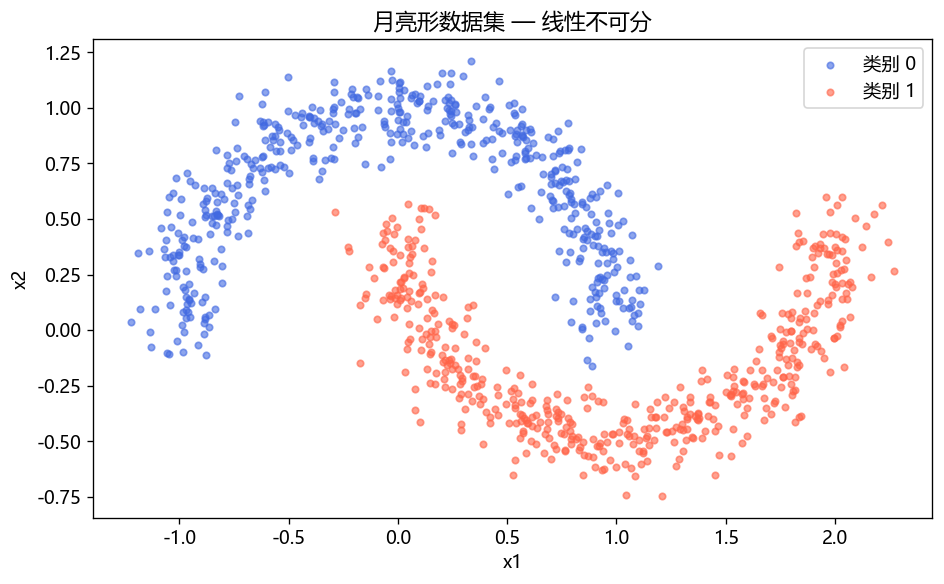

In [4]:
# 生成月亮形数据集
n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

# 转换为 PyTorch 张量 (Tensor)
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

print(f"数据形状: X={X_tensor.shape}, y={y_tensor.shape}")
print(f"特征维度: {X_tensor.shape[1]} (x坐标, y坐标)")

# 可视化
plt.figure(figsize=(8, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='royalblue', label='类别 0', alpha=0.6, s=15)
plt.scatter(X[y==1, 0], X[y==1, 1], c='tomato', label='类别 1', alpha=0.6, s=15)
plt.legend()
plt.title('月亮形数据集 — 线性不可分')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()
plt.show()

### 1.2 搭建神经网络

我们用一个简单的多层感知机 (MLP)：

```
输入 (2维) → 隐藏层1 (32) → ReLU → 隐藏层2 (16) → ReLU → 输出 (1) → Sigmoid
```

In [5]:
# 定义神经网络
model = nn.Sequential(
    nn.Linear(2, 32),    # 输入层 -> 隐藏层1
    nn.ReLU(),           # 激活函数: max(0, x)
    nn.Linear(32, 16),   # 隐藏层1 -> 隐藏层2
    nn.ReLU(),
    nn.Linear(16, 1),    # 隐藏层2 -> 输出层
    nn.Sigmoid()         # 输出概率 (0~1)
)

print("模型结构:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数量: {total_params}")
print(f"\n企业视角: GPT-4 有约 1.8 万亿参数，我们这个只有 {total_params} 个，但核心训练循环是一致的。")

模型结构:
Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

总参数量: 641

企业视角: GPT-4 有约 1.8 万亿参数，我们这个只有 641 个，但核心训练循环是一致的。


### 1.3 训练循环四步曲

| 步骤 | 代码 | 含义 |
|------|------|------|
| **Forward** | `y_pred = model(X)` | 数据过一遍网络，得到预测 |
| **Loss** | `loss = criterion(y_pred, y)` | 计算预测与真实值的差距 |
| **Backward** | `loss.backward()` | 计算每个参数的梯度（该往哪个方向调） |
| **Step** | `optimizer.step()` | 根据梯度更新参数 |

### Backward 的数学含义

训练循环里的 `loss.backward()` 不是单独的一行“黑箱代码”，它做的是链式法则。

如果一层计算是：

$$
z = f(x, y), \qquad L = \text{loss}(z)
$$

反向传播会先拿到上游梯度：

$$
\delta_z = \frac{\partial L}{\partial z}
$$

再把它乘上本层的局部导数，传给每个输入：

$$
\frac{\partial L}{\partial x} += \delta_z \frac{\partial z}{\partial x},
\qquad
\frac{\partial L}{\partial y} += \delta_z \frac{\partial z}{\partial y}
$$

对于一层线性模型：

$$
\hat{y} = xW + b
$$

若从 loss 传回来的梯度是

$$
\delta = \frac{\partial L}{\partial \hat{y}}
$$

则参数梯度可以写成：

$$
\frac{\partial L}{\partial W} = x^T\delta,
\qquad
\frac{\partial L}{\partial b} = \sum_i \delta_i
$$

最后 `optimizer.step()` 按下面的形式更新参数：

$$
\theta_{new} = \theta_{old} - \eta \frac{\partial L}{\partial \theta}
$$

课堂上只要记住一句话：Backward 负责算“每个参数该怎么改”，Step 负责“真的把参数改掉”。

In [6]:
# 定义损失函数和优化器
criterion = nn.BCELoss()  # 二分类交叉熵损失 (Binary Cross Entropy)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam 优化器

print("损失函数: BCELoss（衡量预测概率与真实标签的差距）")
print("优化器: Adam（自适应学习率，企业中最常用）")
print("学习率: 0.01（每次参数更新的步长）")

损失函数: BCELoss（衡量预测概率与真实标签的差距）
优化器: Adam（自适应学习率，企业中最常用）
学习率: 0.01（每次参数更新的步长）


## 训练 练习 1：补全训练循环四步曲（10分钟）⭐

**目标**：在下方代码中填写训练循环的四个关键步骤

**步骤**：
1. Forward：用模型对 `X_tensor` 做前向传播，得到预测值
2. Loss：用 `criterion` 计算预测值与真实值 `y_tensor` 的损失
3. Backward：先清空梯度 `optimizer.zero_grad()`，再反向传播 `loss.backward()`
4. Step：用优化器更新参数 `optimizer.step()`

**预期输出**：
```
Epoch 100 | Loss: 0.0xxx | Accuracy: 1.0000
...
OK 验证通过！最终准确率: 1.0000
```

<details>
<summary>提示: 提示1：思路方向</summary>

四步分别对应：`model(输入)`, `criterion(预测, 真实)`, `loss.backward()`, `optimizer.step()`

</details>

<details>
<summary>提示: 提示2：关键代码</summary>

```python
y_pred = model(数据)
loss = criterion(y_pred, 标签)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

</details>

<details>
<summary>提示: 提示3：参考答案</summary>

```python
outputs = model(X_tensor)
loss = criterion(outputs, y_tensor)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

</details>

In [7]:
# ============================================================
# 练习 1 | 训练循环四步曲
# ============================================================
#
# 【基础】(人人必做，5 min)
#   补全 basic_step：Forward → Loss → Backward → Step 4 步
#   提示：
#     - model(X) 返回预测 (N, 1)
#     - criterion(预测, 真值) 返回标量 loss
#     - loss.backward() 计算梯度
#
# 【进阶】(技术学员选做，10 min)
#   在 advanced_step 加入梯度裁剪：
#   反向传播后用 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
#   再调 optimizer.step()。这是工业界训练大模型时防梯度爆炸的标准做法。
# ============================================================
import time, copy

def basic_step(model, X, y, criterion, optimizer):
    """【基础】训练循环的一步：Forward → Loss → Backward → Step"""
    # ↓↓↓ 【基础】填空（4 行）↓↓↓
    outputs = model(X)
    loss = criterion(outputs, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # ↑↑↑ 【基础】结束 ↑↑↑
    return outputs, loss


def advanced_step(model, X, y, criterion, optimizer, max_norm=1.0):
    """【进阶】训练步含梯度裁剪 (clip_grad_norm_) — 防梯度爆炸"""
    # ↓↓↓ 【进阶】填空（5 行）↓↓↓
    outputs = model(X)
    loss = criterion(outputs, y)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
    optimizer.step()
    # ↑↑↑ 【进阶】结束 ↑↑↑
    return outputs, loss


# Expose to downstream cells
losses = []

def verify():
    """跑这一格自动判分。【基础】跑 500 轮训练，【进阶】另起 100 轮验证梯度裁剪。"""
    global losses
    print("=" * 56)
    print("【基础】用 basic_step 训练 500 轮")
    print("=" * 56)
    losses.clear()
    start = time.time()
    try:
        for epoch in range(500):
            outputs, loss = basic_step(model, X_tensor, y_tensor, criterion, optimizer)
            losses.append(loss.item())
            if (epoch + 1) % 100 == 0:
                acc = ((outputs > 0.5).float() == y_tensor).float().mean()
                print(f"  Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")
        elapsed = time.time() - start
        assert loss.item() < 0.1, f"Loss 应 < 0.1，得到 {loss.item():.4f}"
        with torch.no_grad():
            final_acc = ((model(X_tensor) > 0.5).float() == y_tensor).float().mean()
        assert final_acc > 0.9, f"准确率应 > 90%，得到 {final_acc:.4f}"
        print(f"  耗时 {elapsed:.2f}s | 最终准确率 {final_acc:.4f}")
        print("OK 基础通过\n")
    except NotImplementedError:
        print("SKIP 基础未实现，停止评测\n")
        return
    except Exception as e:
        print(f"FAIL 基础未通过: {type(e).__name__}: {e}\n")
        return

    print("=" * 56)
    print("【进阶】用 advanced_step (含梯度裁剪) 重训 100 轮")
    print("=" * 56)
    try:
        m2 = copy.deepcopy(model)
        opt2 = torch.optim.SGD(m2.parameters(), lr=0.1)
        for _ in range(100):
            outputs2, loss2 = advanced_step(m2, X_tensor, y_tensor, criterion, opt2)
        # 验证梯度裁剪生效：跑一步后看 grad 范数 ≤ max_norm
        out2, l2 = advanced_step(m2, X_tensor, y_tensor, criterion, opt2, max_norm=1.0)
        total_norm = torch.sqrt(sum((p.grad ** 2).sum() for p in m2.parameters() if p.grad is not None))
        assert total_norm <= 1.0 + 1e-3, f"梯度范数应 ≤ 1.0，得到 {total_norm:.4f}"
        print(f"  最终 loss = {l2.item():.4f} | 梯度范数 = {total_norm:.4f} (≤ 1.0 OK)")
        print("OK 进阶通过")
    except NotImplementedError:
        print("SKIP 进阶跳过（未实现，不影响课程进度）")
    except Exception as e:
        print(f"FAIL 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】用 basic_step 训练 500 轮
  Epoch 100 | Loss: 0.0099 | Acc: 1.0000


  Epoch 200 | Loss: 0.0024 | Acc: 1.0000


  Epoch 300 | Loss: 0.0012 | Acc: 1.0000
  Epoch 400 | Loss: 0.0007 | Acc: 1.0000
  Epoch 500 | Loss: 0.0005 | Acc: 1.0000
  耗时 0.63s | 最终准确率 1.0000
OK 基础通过

【进阶】用 advanced_step (含梯度裁剪) 重训 100 轮


  最终 loss = 0.0005 | 梯度范数 = 0.0009 (≤ 1.0 OK)
OK 进阶通过


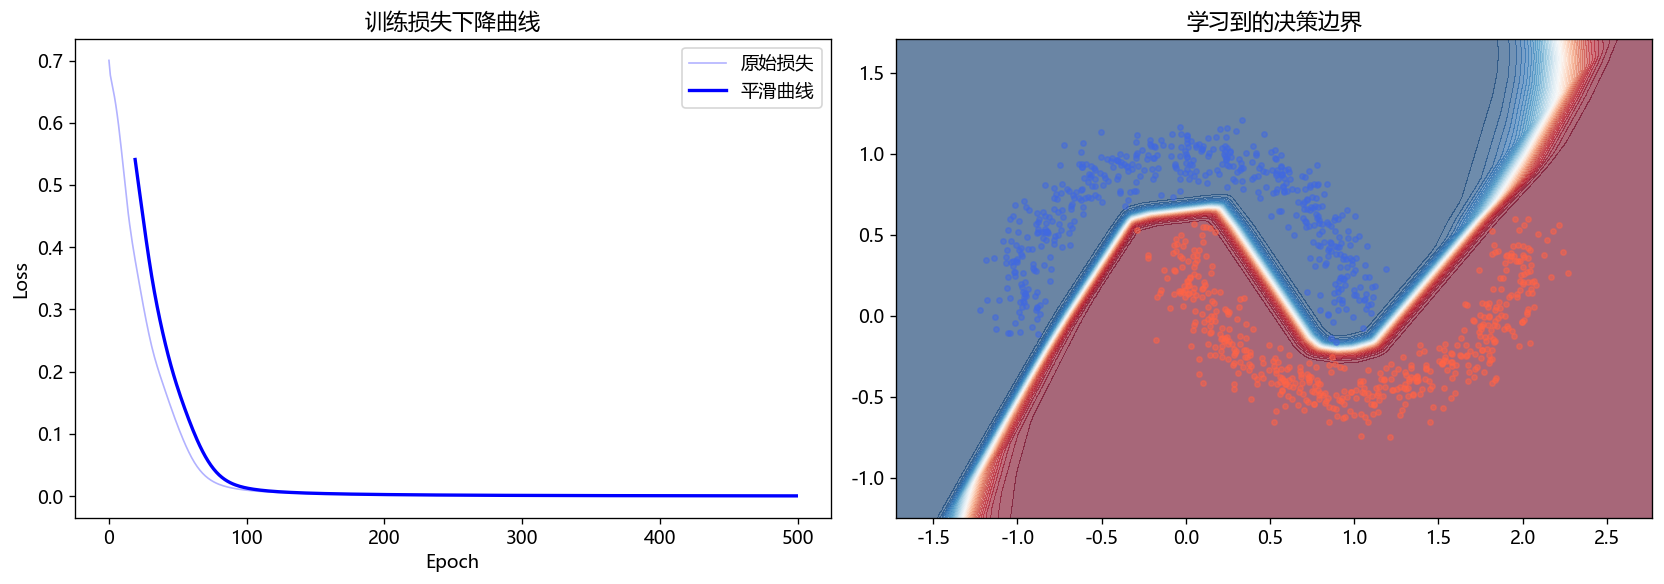

In [8]:
# 可视化训练过程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：Loss 下降曲线
axes[0].plot(losses, color='blue', linewidth=1, alpha=0.3, label='原始损失')
window = 20
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(losses)), smoothed, color='blue', linewidth=2, label='平滑曲线')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练损失下降曲线')
axes[0].legend()

# 右图：决策边界
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

with torch.no_grad():
    Z = model(grid).numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
axes[1].scatter(X[y==0, 0], X[y==0, 1], c='royalblue', s=10, alpha=0.5)
axes[1].scatter(X[y==1, 0], X[y==1, 1], c='tomato', s=10, alpha=0.5)
axes[1].set_title('学习到的决策边界')

plt.tight_layout()
plt.show()

---
## 第二部分：Tokenizer — 文本如何变数字（20 min）

### 核心问题：模型只认数字，文本怎么办？

```
"你好世界" → Tokenizer → [57668, 53901, ...] → 模型 → [1312, ...] → "Hello"
```

### 分词策略对比

| 策略 | 示例 | 优缺点 |
|------|------|--------|
| 字符级 | `["H","e","l","l","o"]` | 词表小，但序列太长 |
| 单词级 | `["Hello", "world"]` | 直观，但词表太大、不能处理新词 |
| **子词级 (BPE)** | `["Hello", ",", "world"]` | 平衡！GPT/LLaMA/Qwen 都用 |

In [9]:
# 演示不同分词策略
text = "Hello, I'm learning machine learning!"

# 1. 字符级
char_tokens = list(text)
print(f"字符级分词 ({len(char_tokens)} tokens): {char_tokens[:10]}...")

# 2. 单词级
word_tokens = text.split()
print(f"单词级分词 ({len(word_tokens)} tokens): {word_tokens}")

# 3. 子词级 (BPE) - 使用 tiktoken
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")  # GPT-4 的编码器
    bpe_tokens = enc.encode(text)
    print(f"BPE 分词 ({len(bpe_tokens)} tokens): {bpe_tokens}")
    print(f"\n解码每个 token:")
    for t in bpe_tokens:
        print(f"  {t}: '{enc.decode([t])}'")
except ImportError:
    print("\n请安装 tiktoken: pip install tiktoken")
    print("BPE 分词示例: [9906, 11, 358, 2846, 6975, 5780, 6975, 0]")

字符级分词 (37 tokens): ['H', 'e', 'l', 'l', 'o', ',', ' ', 'I', "'", 'm']...
单词级分词 (5 tokens): ['Hello,', "I'm", 'learning', 'machine', 'learning!']
BPE 分词 (8 tokens): [9906, 11, 358, 2846, 6975, 5780, 6975, 0]

解码每个 token:
  9906: 'Hello'
  11: ','
  358: ' I'
  2846: ''m'
  6975: ' learning'
  5780: ' machine'
  6975: ' learning'
  0: '!'


In [10]:
# tiktoken 详细演示：看看中文是怎么切分的
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")

    text_cn = "你好！我正在学习大语言模型。"
    tokens = enc.encode(text_cn)

    print(f"原文: {text_cn}")
    print(f"Token IDs ({len(tokens)} tokens): {tokens}")
    print("\n逐 token 显示:")
    for t in tokens:
        token_bytes = enc.decode_single_token_bytes(t)
        try:
            decoded = token_bytes.decode("utf-8")
            shown = repr(decoded)
        except UnicodeDecodeError:
            shown = f"<UTF-8 partial bytes: {token_bytes.hex()}>"
        print(f"  ID {t:>6d} -> {shown:<30} bytes={token_bytes.hex()}")

    print(f"\n注意: {len(text_cn)} 个中文字符 -> {len(tokens)} 个 token")
    print("单个 token 不一定刚好对应一个完整汉字；有时会只是某个汉字的部分 UTF-8 bytes。")
    print(f"中文平均每个字符需要 {len(tokens)/len(text_cn):.1f} 个 token")

except ImportError:
    print("请安装 tiktoken: pip install tiktoken")

原文: 你好！我正在学习大语言模型。
Token IDs (14 tokens): [57668, 53901, 6447, 37046, 97655, 48864, 18259, 254, 27384, 73981, 78244, 54872, 25287, 1811]

逐 token 显示:
  ID  57668 -> '你'                            bytes=e4bda0
  ID  53901 -> '好'                            bytes=e5a5bd
  ID   6447 -> '！'                            bytes=efbc81
  ID  37046 -> '我'                            bytes=e68891
  ID  97655 -> '正在'                           bytes=e6ada3e59ca8
  ID  48864 -> '学'                            bytes=e5ada6
  ID  18259 -> <UTF-8 partial bytes: e4b9>    bytes=e4b9
  ID    254 -> <UTF-8 partial bytes: a0>      bytes=a0
  ID  27384 -> '大'                            bytes=e5a4a7
  ID  73981 -> '语'                            bytes=e8afad
  ID  78244 -> '言'                            bytes=e8a880
  ID  54872 -> '模'                            bytes=e6a8a1
  ID  25287 -> '型'                            bytes=e59e8b
  ID   1811 -> '。'                            bytes=e38082

注意: 14 个中文字符 -> 14 个 to

In [11]:
# 不同语言的 Token 效率对比
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    
    texts = {
        "English": "Machine learning is a branch of artificial intelligence.",
        "Chinese": "机器学习是人工智能的一个分支。",
        "Code": "def hello(): return 'Hello, World!'",
        "Mixed": "GPT-4的参数量约为1.8万亿",
    }
    
    print("不同语言的 Token 效率:")
    print("=" * 60)
    
    for lang, text in texts.items():
        tokens = enc.encode(text)
        ratio = len(text) / len(tokens)
        print(f"\n{lang}:")
        print(f"  文本: {text}")
        print(f"  字符数: {len(text)} | Token 数: {len(tokens)}")
        print(f"  效率: {ratio:.2f} 字符/token")
    
    print("\n" + "=" * 60)
    print("企业启示: 中文 token 效率低 → API 调用成本更高!")
    print("选择中文优化的模型（如 Qwen）可以降低 token 消耗。")
    
except ImportError:
    print("请安装 tiktoken: pip install tiktoken")
    print("\n预期结果:")
    print("English: ~5.2 字符/token")
    print("Chinese: ~1.5 字符/token (效率较低，成本更高)")
    print("Code:    ~3.8 字符/token")

不同语言的 Token 效率:

English:
  文本: Machine learning is a branch of artificial intelligence.
  字符数: 56 | Token 数: 9
  效率: 6.22 字符/token

Chinese:
  文本: 机器学习是人工智能的一个分支。
  字符数: 15 | Token 数: 16
  效率: 0.94 字符/token

Code:
  文本: def hello(): return 'Hello, World!'
  字符数: 35 | Token 数: 9
  效率: 3.89 字符/token

Mixed:
  文本: GPT-4的参数量约为1.8万亿
  字符数: 16 | Token 数: 14
  效率: 1.14 字符/token

企业启示: 中文 token 效率低 → API 调用成本更高!
选择中文优化的模型（如 Qwen）可以降低 token 消耗。


---

> 提示: **小常识（已替代原 Token 单价估算练习）：** 中文文本约 1.3-1.6 个字符 / token（取决于 tokenizer），比英文略贵。选模型时记得用 `tiktoken` 或厂商工具实测自己语料的 token 数。**本课程不展开商业 ROI 估算**——把时间留给原理与实操。

---
## 休息（10 min）

---
## 第三部分：Embedding — 查表 + 语义空间（20 min）

### 核心问题：Token ID 只是编号，怎么表达语义？

答案：给每个 token 分配一个**向量** (Embedding)，让相似的词有相似的向量。

```
"猫" → token_id: 123 → 查 Embedding 表 → [0.2, -0.1, 0.8, ...] (512维向量)
"狗" → token_id: 456 → 查 Embedding 表 → [0.3, -0.2, 0.7, ...] (相似的向量！)
```

`nn.Embedding` 本质就是一个**可学习的查表矩阵**，形状为 `[词表大小, 向量维度]`。

In [12]:
# Embedding 的本质：查表
vocab_size = 10   # 词表大小
embed_dim = 4     # 每个词用 4 维向量表示

embedding = nn.Embedding(vocab_size, embed_dim)

print("Embedding 矩阵形状:", embedding.weight.shape)
print(f"→ {vocab_size} 个词，每个用 {embed_dim} 维向量表示")
print("\nEmbedding 矩阵内容（随机初始化）:")
print(embedding.weight.data)

Embedding 矩阵形状: torch.Size([10, 4])
→ 10 个词，每个用 4 维向量表示

Embedding 矩阵内容（随机初始化）:
tensor([[-0.0384,  1.9138,  0.3378,  0.1251],
        [-0.7622, -1.1906,  0.7756, -0.9437],
        [ 0.2503, -1.3611,  1.8018, -0.0743],
        [-0.1566, -0.8708, -0.6411,  0.5374],
        [-0.6902, -0.2300, -2.1723,  0.0877],
        [ 1.0938, -0.1177, -0.2986,  1.5193],
        [-0.4252, -0.3753,  1.4467, -0.7872],
        [ 2.4992, -0.3020,  0.2207,  0.1513],
        [ 1.2271, -0.5723, -0.1707, -0.4587],
        [-0.1544, -0.2131, -0.8880, -0.1087]])


In [13]:
# Embedding 就是查表！
word_idx = torch.tensor([0, 3, 5])  # 要查的词索引

# 方法1: 使用 Embedding 层
result1 = embedding(word_idx)

# 方法2: 直接索引矩阵（完全等价！）
result2 = embedding.weight[word_idx]

print("查询词索引:", word_idx.tolist())
print("\n方法1 - embedding(idx):")
print(result1.data)
print("\n方法2 - weight[idx]:")
print(result2.data)
print("\n两种方法完全等价:", torch.allclose(result1, result2))
print("\n结论: nn.Embedding 本质就是矩阵索引，没有任何复杂计算！")

查询词索引: [0, 3, 5]

方法1 - embedding(idx):
tensor([[-0.0384,  1.9138,  0.3378,  0.1251],
        [-0.1566, -0.8708, -0.6411,  0.5374],
        [ 1.0938, -0.1177, -0.2986,  1.5193]])

方法2 - weight[idx]:
tensor([[-0.0384,  1.9138,  0.3378,  0.1251],
        [-0.1566, -0.8708, -0.6411,  0.5374],
        [ 1.0938, -0.1177, -0.2986,  1.5193]])

两种方法完全等价: True

结论: nn.Embedding 本质就是矩阵索引，没有任何复杂计算！


### 3.2 训练词向量：通过预测下一个词来学习语义

Embedding 矩阵的值是通过训练学到的。训练目标：**预测下一个词**。

```
"机器" → 模型 → 预测 "学习"（高概率）
"深度" → 模型 → 预测 "学习"（高概率）
```

因为 "机器" 和 "深度" 经常预测同样的下一个词，训练后它们的向量会很相似。

In [14]:
# 准备训练数据
text = """
机器学习是人工智能的核心
深度学习是机器学习的分支
神经网络是深度学习的基础
人工智能改变世界
机器学习改变生活
"""

# 按字符分词
words = list(text.replace('\n', '').replace(' ', ''))
vocab = sorted(set(words))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)

print(f"词表大小: {vocab_size}")
print(f"词表: {vocab}")

# 构建 (当前词, 下一个词) 训练对
X_emb, Y_emb = [], []
for i in range(len(words) - 1):
    X_emb.append(word2idx[words[i]])
    Y_emb.append(word2idx[words[i+1]])

X_emb = torch.tensor(X_emb)
Y_emb = torch.tensor(Y_emb)
print(f"\n训练样本数: {len(X_emb)}")
print(f"前5个样本:")
for i in range(5):
    print(f"  '{idx2word[X_emb[i].item()]}' → '{idx2word[Y_emb[i].item()]}'")

词表大小: 28
词表: ['世', '习', '人', '分', '变', '器', '基', '学', '工', '度', '心', '支', '改', '是', '智', '机', '核', '活', '深', '生', '界', '的', '础', '神', '经', '络', '网', '能']

训练样本数: 51
前5个样本:
  '机' → '器'
  '器' → '学'
  '学' → '习'
  '习' → '是'
  '是' → '人'


In [15]:
# Bigram 语言模型：预测下一个词
class BigramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, x):
        emb = self.embedding(x)       # [batch] → [batch, embed_dim]
        logits = self.linear(emb)     # [batch, embed_dim] → [batch, vocab_size]
        return logits

embed_dim = 16
bigram_model = BigramModel(vocab_size, embed_dim)
print(f"模型参数量: {sum(p.numel() for p in bigram_model.parameters())}")

模型参数量: 924


In [16]:
# 训练 Bigram 模型
optimizer = torch.optim.Adam(bigram_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(500):
    logits = bigram_model(X_emb)
    loss = criterion(logits, Y_emb)
    losses.append(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

print(f"\n训练完成! 最终 Loss: {losses[-1]:.4f}")

Epoch 100 | Loss: 0.3033


Epoch 200 | Loss: 0.2920

Epoch 300 | Loss: 0.2895


Epoch 400 | Loss: 0.2885
Epoch 500 | Loss: 0.2881

训练完成! 最终 Loss: 0.2881


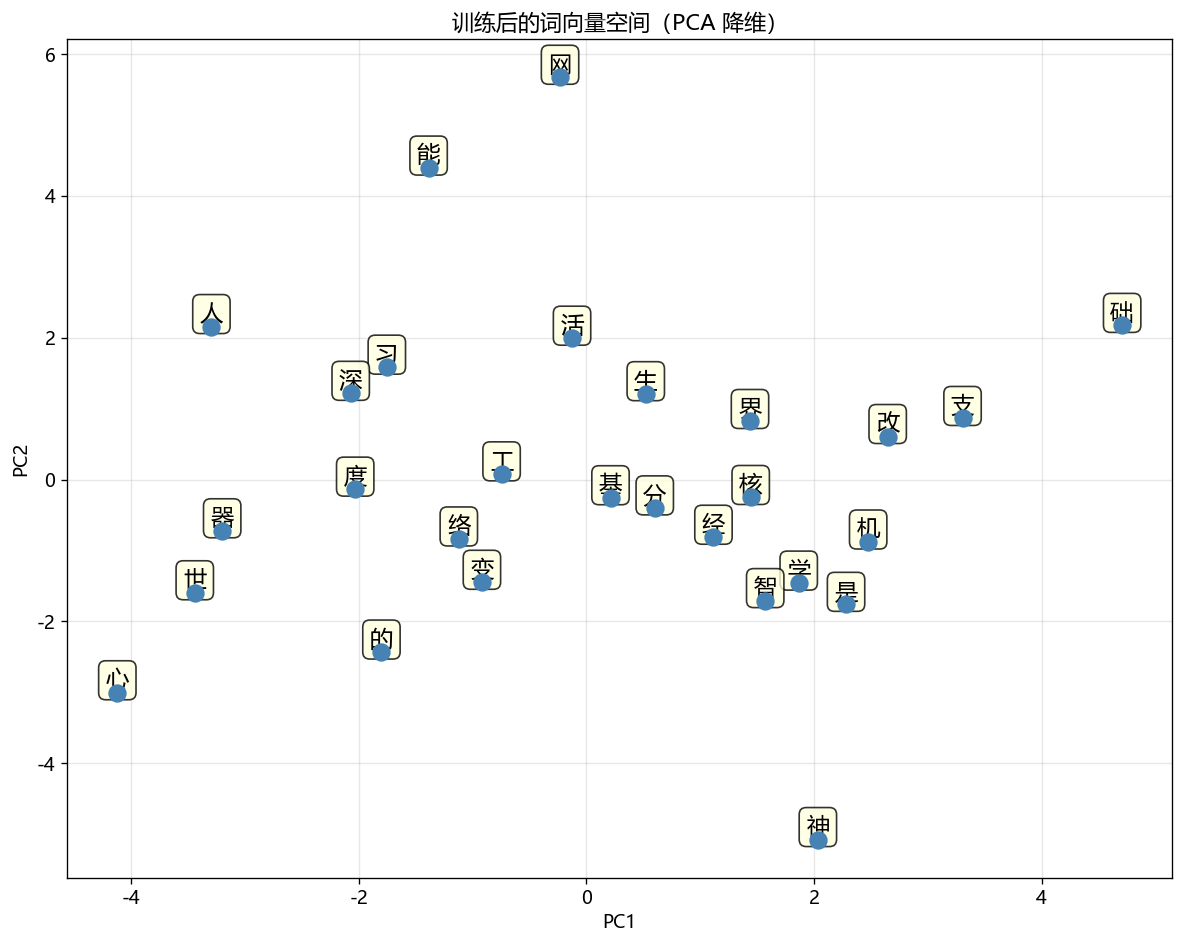

观察: 语义相关的词（如'机'和'器'，'学'和'习'）在空间中更接近。


In [17]:
# 可视化学到的词向量
from sklearn.decomposition import PCA

word_vectors = bigram_model.embedding.weight.detach().numpy()

# 用 PCA 降到 2 维可视化
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], c='steelblue', s=100, zorder=5)

for i, word in enumerate(vocab):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
                fontsize=14, ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.title('训练后的词向量空间（PCA 降维）')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("观察: 语义相关的词（如'机'和'器'，'学'和'习'）在空间中更接近。")

---
## 训练 练习 3：实现余弦相似度（10分钟）⭐

**目标**：实现余弦相似度函数，并用它查找词向量空间中最相似的词

**公式**：

$$\text{cos\_sim}(a, b) = \frac{a \cdot b}{|a| \times |b|}$$

- 返回 1：方向完全相同
- 返回 0：正交（无关）
- 返回 -1：方向完全相反

**步骤**：
1. 补全 `cosine_similarity(v1, v2)` 函数（计算点积、范数、返回商）
2. 通过基础验证用例
3. 用该函数找出词表中与"学"和"机"最相似的词

**预期输出**：
```
cos_sim(v, v) = 1.0000  (应为 1.0)
cos_sim(v, -v) = -1.0000  (应为 -1.0)
OK 基础验证通过！

与 '学' 最相似的词:
  习: 0.xxxx
  ...
```

<details>
<summary>提示: 提示1：思路方向</summary>

需要用到 `np.dot()` 计算点积，`np.linalg.norm()` 计算向量长度

</details>

<details>
<summary>提示: 提示2：关键代码</summary>

```python
dot_product = np.dot(v1, v2)
norm1 = np.linalg.norm(v1)
norm2 = np.linalg.norm(v2)
similarity = dot_product / (norm1 * norm2)
```

</details>

<details>
<summary>提示: 提示3：参考答案</summary>

```python
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
```

</details>

In [18]:
# ============================================================
# 练习 3 | 余弦相似度：从单对到批量
# ============================================================
#
# 【基础】(人人必做，5 min)
#   实现 cosine_similarity(v1, v2) → 返回标量
#   公式：cos(v1, v2) = (v1 · v2) / (||v1|| × ||v2||)
#   提示：np.dot 算点积；np.linalg.norm 算 L2 范数
#
# 【进阶】(技术学员选做，10 min)
#   实现 cosine_similarity_batch(query, matrix) → 返回 shape (N,)
#   query 是单个向量，matrix 是 (N, D) 矩阵；一次性算 query 与每行的相似度
#   提示：用矩阵运算避免 for 循环；matrix @ query 一步算所有点积
# ============================================================

def cosine_similarity(v1, v2):
    """【基础】计算两个向量的余弦相似度，返回标量 float"""
    # ↓↓↓ 【基础】填空（约 4 行）↓↓↓
    dot_product = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    return dot_product / (norm1 * norm2)
    # ↑↑↑ 【基础】结束 ↑↑↑


def cosine_similarity_batch(query, matrix):
    """【进阶】批量计算 query 与 matrix 每行的余弦相似度，返回 shape (N,)"""
    # ↓↓↓ 【进阶】填空（3 行；用矩阵运算）↓↓↓
    query_norm = query / np.linalg.norm(query)
    matrix_norm = matrix / np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix_norm @ query_norm
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    test_vec = np.array([1.0, 2.0, 3.0])

    print("=" * 56)
    print("【基础】cosine_similarity")
    print("=" * 56)
    try:
        sim_same = cosine_similarity(test_vec, test_vec)
        sim_opp = cosine_similarity(test_vec, -test_vec)
        sim_orth = cosine_similarity(np.array([1.0, 0.0]), np.array([0.0, 1.0]))
        print(f"  cos(v, v)   = {sim_same:.4f}  (期望 1.0)")
        print(f"  cos(v, -v)  = {sim_opp:.4f}  (期望 -1.0)")
        print(f"  cos([1,0],[0,1]) = {sim_orth:.4f}  (期望 0.0)")
        assert abs(sim_same - 1.0) < 1e-6
        assert abs(sim_opp + 1.0) < 1e-6
        assert abs(sim_orth) < 1e-6
        print("OK 基础通过\n")
    except NotImplementedError:
        print("SKIP 基础未实现\n"); return
    except Exception as e:
        print(f"FAIL 基础未通过: {e}\n"); return

    print("=" * 56)
    print("【进阶】cosine_similarity_batch")
    print("=" * 56)
    try:
        np.random.seed(0)
        Q = np.random.randn(8)
        M = np.random.randn(20, 8)
        sims = cosine_similarity_batch(Q, M)
        # 跟单对版本逐行对比
        sims_ref = np.array([cosine_similarity(Q, M[i]) for i in range(20)])
        diff = np.abs(sims - sims_ref).max()
        print(f"  shape: {sims.shape} (期望 (20,))")
        print(f"  与基础版逐对结果最大差: {diff:.2e} (期望 < 1e-6)")
        assert sims.shape == (20,)
        assert diff < 1e-6
        print("OK 进阶通过")
    except NotImplementedError:
        print("SKIP 进阶跳过（未实现）")
    except Exception as e:
        print(f"FAIL 进阶未通过: {type(e).__name__}: {e}")

verify()

# ──── 练习应用：用 cosine_similarity 找相似词（与原版一致） ────
def find_similar(word, top_k=5):
    if word not in word2idx:
        print(f"词 '{word}' 不在词表中"); return
    word_vec = word_vectors[word2idx[word]]
    similarities = []
    for w in vocab:
        if w != word:
            sim = cosine_similarity(word_vec, word_vectors[word2idx[w]])
            similarities.append((w, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    print(f"\n与 '{word}' 最相似的词:")
    for w, sim in similarities[:top_k]:
        print(f"  {w}: {sim:.4f}")

find_similar('学')
find_similar('机')


【基础】cosine_similarity
  cos(v, v)   = 1.0000  (期望 1.0)
  cos(v, -v)  = -1.0000  (期望 -1.0)
  cos([1,0],[0,1]) = 0.0000  (期望 0.0)
OK 基础通过

【进阶】cosine_similarity_batch
  shape: (20,) (期望 (20,))
  与基础版逐对结果最大差: 2.22e-16 (期望 < 1e-6)
OK 进阶通过

与 '学' 最相似的词:
  络: 0.2336
  支: 0.2210
  神: 0.2177
  机: 0.1803
  心: 0.1558

与 '机' 最相似的词:
  分: 0.2166
  神: 0.2073
  核: 0.1881
  改: 0.1833
  学: 0.1803


---
## 训练 练习 4：用预训练 Embedding 找语义相似句（10分钟）⭐⭐

**目标**：使用预训练 Embedding 模型计算句子间的语义相似度，并按相似度排序

刚才我们训练了一个非常小的词向量。实际企业中，会使用**预训练好的 Embedding 模型**，如阿里百炼的 `text-embedding-v3`。

**步骤**：
1. 用 `env.get_embedder()` 获取 Embedding 后端
2. 用 `embedder.embed(sentences)` 获取句子向量
3. 用练习3实现的 `cosine_similarity` 计算查询句与每个句子的相似度，按高到低排序
4. （加分）用 KMeans 对句子聚类

**预期输出**：
```
查询: 'AI 技术帮助企业提高效率'

相似度排名:
  0.xxxx | 机器学习可以分析大量数据
  0.xxxx | 数据挖掘帮助企业做决策
  ...
```

> 注意：此练习需要已配置 API Key，请确保已运行 Day0 环境配置。

<details>
<summary>提示: 提示1：思路方向</summary>

用 `embedder.embed(sentences)` 获取向量列表，用你实现的 `cosine_similarity` 计算相似度

</details>

<details>
<summary>提示: 提示2：关键代码</summary>

```python
vectors = embedder.embed(sentences)
query_vec = embedder.embed([query])[0]
for i, sent in enumerate(sentences):
    sim = cosine_similarity(np.array(query_vec), np.array(vectors[i]))
```

</details>

<details>
<summary>提示: 提示3：参考答案（含聚类加分）</summary>

```python
vectors = embedder.embed(sentences)
query_vec = embedder.embed([query])[0]
results = []
for i, sent in enumerate(sentences):
    sim = cosine_similarity(np.array(query_vec), np.array(vectors[i]))
    results.append((sim, sent))
results.sort(reverse=True)

# 聚类加分
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(np.array(vectors))
```

</details>

In [19]:
# ============================================================
# 练习 4 | 用预训练 Embedding 做语义检索
# ============================================================
#
# 【基础】(人人必做，5 min)
#   用 embedder.embed(...) 把句子向量化，然后用 cosine_similarity 排序找最相关
#
# 【进阶】(技术学员选做，10 min)
#   用 cosine_similarity_batch + np.argsort 实现 top-k 检索
#   要求：用矩阵乘法一次算 query 与所有句子的相似度，避免 for 循环
# ============================================================

embedder = env.get_embedder()

sentences = [
    "机器学习可以分析大量数据",
    "深度学习是人工智能的重要分支",
    "今天的天气非常好",
    "数据挖掘帮助企业做决策",
    "公园里的花开了",
]
query = "AI 技术帮助企业提高效率"


def basic_search(query, sentences):
    """【基础】返回 [(sim, sent), ...] 按相似度降序"""
    # ↓↓↓ 【基础】填空（约 6 行）↓↓↓
    vectors = embedder.embed(sentences)
    query_vec = embedder.embed([query])[0]
    results = []
    for i, sent in enumerate(sentences):
        sim = cosine_similarity(np.array(query_vec), np.array(vectors[i]))
        results.append((sim, sent))
    results.sort(reverse=True)
    return results
    # ↑↑↑ 【基础】结束 ↑↑↑


def advanced_topk(query, sentences, k=3):
    """【进阶】用矩阵化 + np.argsort 返回 top-k 列表 [(sim, sent), ...]"""
    # ↓↓↓ 【进阶】填空（4 行；要求用 cosine_similarity_batch）↓↓↓
    matrix = np.array(embedder.embed(sentences))
    q_vec = np.array(embedder.embed([query])[0])
    sims = cosine_similarity_batch(q_vec, matrix)
    topk_idx = np.argsort(-sims)[:k]
    return [(float(sims[i]), sentences[i]) for i in topk_idx]
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】basic_search"); print("=" * 56)
    try:
        results = basic_search(query, sentences)
        print(f"查询: '{query}'\n相似度排名:")
        for sim, sent in results:
            print(f"  {sim:.4f} | {sent}")
        assert len(results) == len(sentences)
        assert results[0][0] >= results[-1][0], "排序应降序"
        print("OK 基础通过\n")
    except NotImplementedError:
        print("SKIP 基础未实现\n"); return
    except Exception as e:
        print(f"FAIL 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】advanced_topk (k=3)"); print("=" * 56)
    try:
        topk = advanced_topk(query, sentences, k=3)
        for sim, sent in topk:
            print(f"  {sim:.4f} | {sent}")
        assert len(topk) == 3
        # top-1 应与基础版 top-1 同句
        assert topk[0][1] == basic_search(query, sentences)[0][1]
        print("OK 进阶通过")
    except NotImplementedError:
        print("SKIP 进阶跳过（未实现）")
    except Exception as e:
        print(f"FAIL 进阶未通过: {type(e).__name__}: {e}")

verify()


[Embedding] dashscope / text-embedding-v3 (dim=1024)
【基础】basic_search


查询: 'AI 技术帮助企业提高效率'
相似度排名:
  0.6218 | 数据挖掘帮助企业做决策
  0.5692 | 机器学习可以分析大量数据
  0.5193 | 深度学习是人工智能的重要分支
  0.3851 | 今天的天气非常好
  0.3033 | 公园里的花开了
OK 基础通过

【进阶】advanced_topk (k=3)


  0.6218 | 数据挖掘帮助企业做决策
  0.5692 | 机器学习可以分析大量数据
  0.5193 | 深度学习是人工智能的重要分支


OK 进阶通过


---
## 第四部分：Prompt Engineering 速成（20 min）

### 核心问题：有了大模型，很多任务不需要训练，只需要写好提示词 (Prompt)！

三种基本策略：

| 策略 | 说明 | 适用场景 |
|------|------|----------|
| **Zero-shot** | 直接提问，不给示例 | 简单任务 |
| **Few-shot** | 给几个示例，再提问 | 需要特定格式/风格 |
| **Chain-of-Thought** | 要求模型逐步推理 | 复杂推理任务 |

In [20]:
# Initialize LLM backend from Day0 config; fallback to mock for class demos
try:
    llm = env.get_llm()
    _test = llm.generate("hi", max_tokens=5)
    print("[OK] LLM backend ready")
except Exception as e:
    print(f"[!] Configured LLM unavailable: {e}")
    from utils.llm_backend import get_llm_backend
    llm = get_llm_backend("mock")
    print("[OK] Using deterministic mock LLM backend; live API unavailable or quota exhausted.")

[LLM] dashscope / qwen-plus-2025-01-25


[OK] LLM backend ready


In [21]:
# 策略 1: Zero-shot — 直接提问
if llm:
    prompt_zero = "请将以下客户反馈分类为 正面/负面/中性：\n\n'这个产品质量太差了，用了一周就坏了'"
    
    print("=" * 50)
    print("Zero-shot Prompt:")
    print(prompt_zero)
    print("=" * 50)
    
    response = llm.generate(prompt_zero, temperature=0)
    print(f"\n模型回复:\n{response}")
else:
    print("LLM 未初始化，请先运行上方单元格")
    print("\n预期回复: 负面")

Zero-shot Prompt:
请将以下客户反馈分类为 正面/负面/中性：

'这个产品质量太差了，用了一周就坏了'



模型回复:
负面


In [22]:
# 策略 2: Few-shot — 给示例
if llm:
    prompt_few = """请将客户反馈分类为 正面/负面/中性。

示例:
反馈: "发货很快，包装完好" → 正面
反馈: "产品有划痕，不太满意" → 负面
反馈: "还行吧，一般般" → 中性

请分类:
反馈: "客服态度非常好，问题很快解决了"
分类:"""
    
    print("=" * 50)
    print("Few-shot Prompt:")
    print(prompt_few)
    print("=" * 50)
    
    response = llm.generate(prompt_few, temperature=0)
    print(f"\n模型回复:\n{response}")
else:
    print("预期回复: 正面")

Few-shot Prompt:
请将客户反馈分类为 正面/负面/中性。

示例:
反馈: "发货很快，包装完好" → 正面
反馈: "产品有划痕，不太满意" → 负面
反馈: "还行吧，一般般" → 中性

请分类:
反馈: "客服态度非常好，问题很快解决了"
分类:



模型回复:
正面


In [23]:
# 策略 3: Chain-of-Thought (CoT) — 逐步推理
if llm:
    prompt_cot = """请分析以下客户反馈，判断情感类别。

反馈: "产品功能很强大，但是价格有点贵，总体来说还是值得购买的"

请按以下步骤分析:
1. 找出正面表述
2. 找出负面表述
3. 判断整体倾向
4. 给出最终分类（正面/负面/中性）"""
    
    print("=" * 50)
    print("Chain-of-Thought Prompt:")
    print(prompt_cot)
    print("=" * 50)
    
    response = llm.generate(prompt_cot, temperature=0)
    print(f"\n模型回复:\n{response}")
else:
    print("预期: 模型会逐步分析正面/负面因素，最终给出分类")

Chain-of-Thought Prompt:
请分析以下客户反馈，判断情感类别。

反馈: "产品功能很强大，但是价格有点贵，总体来说还是值得购买的"

请按以下步骤分析:
1. 找出正面表述
2. 找出负面表述
3. 判断整体倾向
4. 给出最终分类（正面/负面/中性）



模型回复:
### 分析步骤：

#### **1. 找出正面表述**
- "产品功能很强大" → 表明客户对产品的功能感到满意。
- "总体来说还是值得购买的" → 表明客户认为产品的价值超过了缺点。

#### **2. 找出负面表述**
- "价格有点贵" → 表明客户对产品的价格存在一定的不满。

#### **3. 判断整体倾向**
- 客户提到产品功能强大是主要的优点，且最终结论是“值得购买”，这表明尽管价格稍高，但客户仍然认可产品的整体价值。
- 因此，反馈的整体倾向偏正面。

#### **4. 给出最终分类**
- **正面**

### 总结：
该反馈虽然提到了一个负面点（价格贵），但最终评价以正面为主（功能强大、值得购买），因此最终分类为 **正面**。


### Prompt 工程企业实践要点

| 技巧 | 说明 |
|------|------|
| 明确角色 | `"你是一个专业的客服分类系统"` |
| 限制输出格式 | `"只回复：正面/负面/中性"` |
| 给示例 | Few-shot 比 Zero-shot 更稳定 |
| 分步推理 | CoT 适合复杂判断 |
| 控制 temperature | 分类任务用 0，创作任务用 0.7+ |

---
## 训练 练习 5：Prompt工程A/B测试（15分钟）⭐⭐

**目标**：设计两种不同的 Prompt 策略（Few-shot vs Zero-shot），在测试数据上做A/B测试，对比分类准确率

**步骤**：
1. Part A：设计一个 Few-shot prompt 模板 `PROMPT_A`，包含2-3个分类示例
2. Part B：设计一个 Zero-shot prompt 模板 `PROMPT_B`，只有指令无示例
3. 在8条测试投诉上分别用两个 prompt 调用 LLM，记录分类结果
4. 打印对比表格，计算两种策略的准确率

**分类类别**：产品质量 / 物流配送 / 售后服务 / 价格争议 / 账户问题 / 其他

**预期输出**：
```
测试文本              预期      Prompt A   Prompt B   AOK   BOK
收到的商品有明显划痕... 产品质量   产品质量    产品质量    OK    OK
...
准确率: Prompt A = x/8 (xx%), Prompt B = x/8 (xx%)
```

> 注意：此练习需要已配置 API Key，请确保已运行 Day0 环境配置。

<details>
<summary>提示: 提示1：思路方向</summary>

Few-shot prompt 应包含：任务描述 + 2-3个示例（输入->输出）+ 待分类文本。Zero-shot 只需指令 + 待分类文本。

</details>

<details>
<summary>提示: 提示2：关键代码</summary>

```python
full_prompt_a = PROMPT_A.format(text=text)
result_a = llm.generate(full_prompt_a, temperature=0)
a_correct = expected in result_a
```

</details>

<details>
<summary>提示: 提示3：参考答案</summary>

```python
for text, expected in complaints:
    result_a = llm.generate(prompt_a.format(text=text), temperature=0)
    result_b = llm.generate(prompt_b.format(text=text), temperature=0)
    results.append({
        "text": text, "expected": expected,
        "result_a": result_a, "result_b": result_b,
        "a_correct": expected in result_a,
        "b_correct": expected in result_b,
    })
```

</details>

In [24]:
# ============================================================
# 练习 5 | Prompt 工程 A/B 测试 + 进阶 CoT
# ============================================================
#
# 【基础】(人人必做，10 min)
#   设计 2 个 prompt：A=Few-shot (含示例)，B=Zero-shot (纯指令)
#   对比哪个准确率高
#
# 【进阶】(技术学员选做，10 min)
#   再设计 1 个 Chain-of-Thought (CoT) prompt：让模型先『想』再回答
#   对比 A/B/C 三种的准确率，并思考 CoT 的代价（token 多 ≈ 慢且贵）
# ============================================================

# ──── 【基础】设计两个 prompt ────
# ↓↓↓ 【基础】填空：补全 PROMPT_A (Few-shot) 与 PROMPT_B (Zero-shot) ↓↓↓
PROMPT_A = """你是一个客户投诉分类系统。请将客户投诉分类为以下类别之一：产品质量/物流配送/售后服务/价格争议/账户问题/其他

示例：
投诉: "收到的手机屏幕有裂痕" → 产品质量
投诉: "包裹一直没有送到" → 物流配送
投诉: "退款申请没人处理" → 售后服务

请分类以下投诉，只回复类别名称：
投诉: "{text}"
分类:"""

PROMPT_B = """请将以下客户投诉分类为：产品质量/物流配送/售后服务/价格争议/账户问题/其他。只回复类别名称。

投诉: "{text}"
分类:"""
# ↑↑↑ 【基础】结束 ↑↑↑


# ──── 【进阶】设计 CoT prompt ────
# ↓↓↓ 【进阶】填空：补全 PROMPT_C (CoT) ↓↓↓
PROMPT_C = """请将以下客户投诉分类。先用一句话分析投诉的核心问题，再给出分类。

类别：产品质量/物流配送/售后服务/价格争议/账户问题/其他

格式：
分析: <一句话分析>
分类: <类别>

投诉: "{text}"
"""
# ↑↑↑ 【进阶】结束 ↑↑↑


test_complaints = [
    ("收到的商品有明显划痕，包装也破损了", "产品质量"),
    ("快递显示已签收但我没收到", "物流配送"),
    ("申请退款三天了还没处理", "售后服务"),
    ("同样的东西别家便宜很多", "价格争议"),
    ("我的账号突然登不上了", "账户问题"),
    ("产品用了两天就坏了", "产品质量"),
    ("发货太慢了等了一周", "物流配送"),
    ("客服态度很差不解决问题", "售后服务"),
]


def run_prompt(prompt_template, complaints, llm, label=""):
    """跑一个 prompt 在测试集上，返回 (准确率, 详情列表)"""
    if llm is None:
        print(f"  [{label}] LLM 未初始化"); return 0.0, []
    correct = 0
    details = []
    for text, expected in complaints:
        out = llm.generate(prompt_template.format(text=text), temperature=0)
        is_right = expected in out
        if is_right:
            correct += 1
        details.append((text, expected, out.strip()[:30], is_right))
    return correct / len(complaints), details


def verify():
    print("=" * 56); print("【基础】对比 PROMPT_A (Few-shot) vs PROMPT_B (Zero-shot)"); print("=" * 56)
    try:
        acc_a, det_a = run_prompt(PROMPT_A, test_complaints, llm, "A")
        acc_b, det_b = run_prompt(PROMPT_B, test_complaints, llm, "B")
        print(f"\n  准确率:  A (Few-shot) = {acc_a:.0%}   |   B (Zero-shot) = {acc_b:.0%}")
        # 一般 Few-shot 应不弱于 Zero-shot
        assert isinstance(acc_a, float) and isinstance(acc_b, float)
        print("OK 基础通过 — 通常 Few-shot 准确率 ≥ Zero-shot\n")
    except NotImplementedError:
        print("SKIP 基础未实现\n"); return
    except Exception as e:
        print(f"FAIL 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】对比 A/B/C 三种 prompt (含 CoT)"); print("=" * 56)
    try:
        acc_c, det_c = run_prompt(PROMPT_C, test_complaints, llm, "C")
        print(f"\n  准确率:  A = {acc_a:.0%}   |   B = {acc_b:.0%}   |   C (CoT) = {acc_c:.0%}")
        print(f"\n  提示: 思考：CoT 多输出『分析』那一句，token 比 A 多 ~3-5 倍，延迟同步增加。")
        print(f"     在简单分类任务上，Few-shot 通常已够用；CoT 在多跳推理任务才显著占优。")
        print("OK 进阶通过")
    except NotImplementedError:
        print("SKIP 进阶跳过（未实现）")
    except Exception as e:
        print(f"FAIL 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】对比 PROMPT_A (Few-shot) vs PROMPT_B (Zero-shot)



  准确率:  A (Few-shot) = 100%   |   B (Zero-shot) = 100%
OK 基础通过 — 通常 Few-shot 准确率 ≥ Zero-shot

【进阶】对比 A/B/C 三种 prompt (含 CoT)



  准确率:  A = 100%   |   B = 100%   |   C (CoT) = 100%

  提示: 思考：CoT 多输出『分析』那一句，token 比 A 多 ~3-5 倍，延迟同步增加。
     在简单分类任务上，Few-shot 通常已够用；CoT 在多跳推理任务才显著占优。
OK 进阶通过


---
## 第五部分：企业决策框架 — 微调 vs RAG vs Prompt（15 min）

### 三种方案对比

| 维度 | Prompt Engineering | RAG (检索增强生成) | 微调 (Fine-tuning) |
|------|-------------------|-------------------|--------------------|
| **成本** | 最低（API 费用） | 中等（向量数据库 + API） | 最高（GPU + 标注数据） |
| **开发周期** | 小时级 | 天级 | 周~月级 |
| **数据需求** | 无需训练数据 | 需要知识库文档 | 需要标注数据（通常 1000+） |
| **准确率** | 中等 | 中高（依赖知识库质量） | 最高 |
| **可定制性** | 低 | 中 | 高 |
| **维护成本** | 低 | 中（需更新知识库） | 高（需重新训练） |

### 决策流程图

```
你的任务是什么？
  ├─ 通用任务（翻译/摘要/对话）→ 直接用 Prompt Engineering
  ├─ 需要最新/专有知识？ → RAG
  │    └─ 知识库文档 < 100 页？ → 直接放进 context（长上下文模型）
  │    └─ 知识库文档 > 100 页？ → 搭建向量数据库 + RAG
  ├─ 需要特定风格/格式？ → Few-shot Prompt 先试
  │    └─ Few-shot 不够好？ → 考虑微调
  └─ 需要极高准确率 + 大量数据？ → 微调（SFT/LoRA）
```

### 企业快速决策清单

1. **先试 Prompt**：80% 的任务用好 prompt 就够了
2. **数据量少 (<100条)**：Few-shot > Fine-tuning
3. **需要实时知识**：RAG 是唯一选择
4. **对延迟敏感**：微调小模型 > 调用大模型 API
5. **预算有限**：Prompt > RAG > 微调

In [25]:
# 企业场景决策练习
scenarios = [
    {
        "场景": "电商客服自动回复，需要查询订单信息和退换货政策",
        "推荐": "RAG",
        "原因": "需要实时查询订单数据 + 公司政策文档，Prompt 无法获取实时信息"
    },
    {
        "场景": "将客户邮件翻译成英文",
        "推荐": "Prompt Engineering",
        "原因": "翻译是通用能力，大模型已经做得很好，不需要额外训练"
    },
    {
        "场景": "医疗影像报告自动生成，需要符合特定医院的格式规范",
        "推荐": "微调 (Fine-tuning)",
        "原因": "需要极高准确率 + 特定格式 + 专业领域知识，且有大量历史报告可用于训练"
    },
    {
        "场景": "内部知识库问答，文档约 500 页",
        "推荐": "RAG",
        "原因": "文档量大无法全部放进 context，需要检索最相关的片段"
    },
]

print("企业 AI 场景决策示例")
print("=" * 60)
for s in scenarios:
    print(f"\n场景: {s['场景']}")
    print(f"推荐方案: {s['推荐']}")
    print(f"原因: {s['原因']}")
    print("-" * 60)

企业 AI 场景决策示例

场景: 电商客服自动回复，需要查询订单信息和退换货政策
推荐方案: RAG
原因: 需要实时查询订单数据 + 公司政策文档，Prompt 无法获取实时信息
------------------------------------------------------------

场景: 将客户邮件翻译成英文
推荐方案: Prompt Engineering
原因: 翻译是通用能力，大模型已经做得很好，不需要额外训练
------------------------------------------------------------

场景: 医疗影像报告自动生成，需要符合特定医院的格式规范
推荐方案: 微调 (Fine-tuning)
原因: 需要极高准确率 + 特定格式 + 专业领域知识，且有大量历史报告可用于训练
------------------------------------------------------------

场景: 内部知识库问答，文档约 500 页
推荐方案: RAG
原因: 文档量大无法全部放进 context，需要检索最相关的片段
------------------------------------------------------------


---
## 上午总结

### 今天上午我们走过了从文本到向量的完整路径

```
文本 → Tokenizer → Token IDs → Embedding → 向量 → 模型 → 输出
```

### 关键收获

| 概念 | 一句话总结 |
|------|----------|
| 训练循环 | Forward → Loss → Backward → Step，反复迭代 |
| Tokenizer | 把文本切成子词 (subword)，中文效率低于英文 |
| Embedding | 可学习的查表矩阵，把离散 ID 变成稠密向量 |
| Prompt Engineering | 80% 的任务用好 prompt 就够了 |
| 企业决策 | 先 Prompt → 不够就 RAG → 最后考虑微调 |

### 下午预告

下午我们将深入 **Transformer 架构**，理解让 GPT/Qwen/LLaMA 如此强大的核心机制 —— **Self-Attention（自注意力）**。